# Cell 1

In [ ]:
# =============================================================================
# Thesis — GeoAI Café Site Selection · Milan
# Phase 2 · Notebook 7 · SHAP Computation and AHP vs SHAP Comparison
# =============================================================================
#
# Purpose:
#   This notebook produces the thesis's primary analytical contribution:
#   a formal comparison between expert-driven AHP weights and data-driven
#   SHAP feature importance derived from the trained Random Forest.
#
#   The comparison answers three interrelated questions:
#     1. Do AHP expert weights and RF-learned feature importance agree?
#        (Spearman correlation between AHP weight vector and SHAP ranking)
#     2. Where do they diverge, and what does divergence reveal about
#        the limits of expert intuition for Milan café site selection?
#     3. Which specific cells show the largest AHP vs RF score disagreement,
#        and what spatial pattern explains the divergence?
#
# Two types of SHAP values are computed and used:
#
#   Global SHAP importance:
#     Mean absolute SHAP value per feature across all viable cells.
#     This is the "data-driven weight vector" compared against AHP weights.
#     Produces the core comparison table (Table X in thesis Chapter 4).
#
#   Per-cell SHAP vectors:
#     13-dimensional SHAP attribution per H3 cell.
#     Exported to gold_shap_scores.geojson for WebGIS use.
#     Used to explain individual cell scores in the WebGIS dashboard.
#
# SHAP method used: TreeExplainer
#   - Native to tree-based models (exact, not approximate)
#   - Produces consistent, theoretically grounded attributions
#   - Compatible with SHAP's additivity property:
#     f(x) = base_value + sum(SHAP_i for each feature i)
#   - Background sample = balanced 50/50 training set (size determined by
#     canonical split — see Cell 5 and gold_nb7_log.txt)
#
# Inputs:
#   - gold_features_normalized.geojson  (feature table)
#   - gold_ahp_scores.geojson           (AHP scores and cluster weights)
#   - gold_rf_model.pkl                 (trained Random Forest)
#   - gold_feature_cols.pkl             (feature column order for SHAP)
#   - gold_rf_scores.geojson            (RF probabilities and ranks)
#
# Outputs:
#   - gold_shap_scores.geojson          — per-cell SHAP vectors + all scores
#   - gold_shap_importance.csv          — global SHAP feature importance table
#   - gold_ahp_vs_shap_comparison.csv   — the core thesis comparison table
#   - gold_shap_beeswarm.png            — SHAP beeswarm summary plot
#   - gold_shap_bar.png                 — SHAP mean absolute importance plot
#   - gold_shap_waterfall_top1.png      — waterfall for top AHP cell
#   - gold_shap_waterfall_divergent.png — waterfall for highest divergence cell
#   - gold_nb7_log.txt
#
# CRS: EPSG:4326 (GeoJSON standard — all spatial ops already complete)
# =============================================================================

# Cell 2

In [ ]:
!pip install shap -q
!pip install geopandas -q
!pip install scikit-learn -q
!pip install pandas -q
!pip install numpy -q
!pip install matplotlib -q
!pip install scipy -q
!pip install h3 -q

import os
import datetime
import warnings
import pickle
warnings.filterwarnings('ignore')
os.environ['OGR_GEOJSON_MAX_OBJ_SIZE'] = '0'

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
import h3
from scipy.stats import spearmanr, kendalltau

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/Thesis'
BRONZE_PATH  = os.path.join(PROJECT_ROOT, 'Bronze')
SILVER_PATH  = os.path.join(PROJECT_ROOT, 'Silver')
GOLD_PATH    = os.path.join(PROJECT_ROOT, 'Gold')

RANDOM_SEED  = 42

print(f"Notebook 7 started: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"SHAP version: {shap.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.9 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Notebook 7 started: 2026-04-26 13:00
SHAP version: 0.51.0


# Cell 3

In [ ]:
# =============================================================================
# LOAD ALL GOLD LAYER INPUTS
# =============================================================================

print("Loading Gold layer inputs...")
print()

# Normalized feature table
features = gpd.read_file(
    os.path.join(GOLD_PATH, 'gold_features_normalized.geojson')
)
print(f"Normalized features: {len(features)} cells, "
      f"{len(features.columns)} columns")

# AHP scores
ahp = gpd.read_file(
    os.path.join(GOLD_PATH, 'gold_ahp_scores.geojson')
)
print(f"AHP scores:          {len(ahp)} cells")

# RF scores and ranks
rf_scores = gpd.read_file(
    os.path.join(GOLD_PATH, 'gold_rf_scores.geojson')
)
print(f"RF scores:           {len(rf_scores)} cells")

# Load trained model
model_path = os.path.join(GOLD_PATH, 'gold_rf_model.pkl')
with open(model_path, 'rb') as f:
    rf_model = pickle.load(f)
print(f"RF model loaded:     {rf_model.n_estimators} trees, "
      f"{rf_model.n_features_in_} features")

# Load feature column order (must match training order exactly)
feature_cols_path = os.path.join(GOLD_PATH, 'gold_feature_cols.pkl')
with open(feature_cols_path, 'rb') as f:
    FEATURE_COLS = pickle.load(f)
print(f"Feature columns:     {len(FEATURE_COLS)} features")
print(f"  {FEATURE_COLS}")

# Merge all scores onto features table
features = features.merge(
    ahp[['h3_id', 'ahp_score', 'ahp_rank',
         'score_accessibility', 'score_demand',
         'score_urban', 'score_competition']],
    on='h3_id', how='left'
)
features = features.merge(
    rf_scores[['h3_id', 'rf_probability', 'rf_rank', 'rank_diff']],
    on='h3_id', how='left'
)

print(f"\nMerged table: {features.shape}")
print("All inputs loaded successfully")

Loading Gold layer inputs...

Normalized features: 971 cells, 20 columns
AHP scores:          971 cells
RF scores:           971 cells
RF model loaded:     200 trees, 13 features
Feature columns:     13 features
  ['metro_count_norm', 'transit_density_norm', 'network_centrality_norm', 'pop_density_norm', 'night_light_norm', 'retail_density_norm', 'tourist_poi_count_norm', 'poi_diversity_norm', 'pedestrian_street', 'competitor_saturation_inv_norm', 'local_cafe_density_norm', 'office_density_norm', 'university_proximity_norm']

Merged table: (971, 29)
All inputs loaded successfully


# Cell 4

In [ ]:
print("Building feature matrix for SHAP...")
print()

# Verify all feature columns are present
missing = [c for c in FEATURE_COLS if c not in features.columns]
if missing:
    raise ValueError(f"Missing feature columns: {missing}. "
                     f"Ensure gold_features_normalized.geojson is up to date.")

X_all = features[FEATURE_COLS].fillna(0).values
y_all = features['label'].values

print(f"Feature matrix X_all: {X_all.shape}")
print(f"Labels y_all: {y_all.shape}  "
      f"({y_all.sum()} positive, {(y_all==0).sum()} negative)")
print()

# Human-readable label mapping for plots
# competitor_saturation_inv_norm replaces competitor_saturation_norm
FEATURE_DISPLAY_NAMES = {
    'metro_count_norm':                'Metro Access',
    'transit_density_norm':            'Bus/Tram Density',
    'network_centrality_norm':         'Network Centrality',
    'pop_density_norm':                'Population Density',
    'office_density_norm':             'Office Density',
    'university_proximity_norm':       'University Proximity',
    'night_light_norm':                'Night Light (VIIRS)',
    'retail_density_norm':             'Retail Density',
    'tourist_poi_count_norm':          'Tourist POIs',
    'poi_diversity_norm':              'POI Diversity',
    'local_cafe_density_norm':         'Café Density (local)',
    'competitor_saturation_inv_norm':  'Competitor Saturation (inv.)',
    'pedestrian_street':               'Pedestrian Street',
}

# AHP cluster assignment — Phase 2
# office_density_norm and university_proximity_norm are RF-only in Phase 2;
# they have no AHP sub-weight and must not inflate the Demand Potential cluster share.
# Canonical RF-only string: 'RF-only' — matches AHP_SUB_WEIGHTS (None → 'RF-only') throughout.
AHP_CLUSTER_MAP = {
    'metro_count_norm':               'Accessibility',
    'transit_density_norm':           'Accessibility',
    'network_centrality_norm':        'Accessibility',
    'pop_density_norm':               'Demand Potential',
    'office_density_norm':            'RF-only',
    'university_proximity_norm':      'RF-only',
    'night_light_norm':               'Demand Potential',
    'retail_density_norm':            'Urban Context',
    'tourist_poi_count_norm':         'Urban Context',
    'poi_diversity_norm':             'Urban Context',
    'pedestrian_street':              'Urban Context',
    'local_cafe_density_norm':        'RF-only',
    'competitor_saturation_inv_norm': 'Competition',
}

display_names = [FEATURE_DISPLAY_NAMES.get(c, c) for c in FEATURE_COLS]
print("Feature display names:")
for col, disp in zip(FEATURE_COLS, display_names):
    print(f"  {col:<45} → {disp}")

Building feature matrix for SHAP...

Feature matrix X_all: (971, 13)
Labels y_all: (971,)  (345 positive, 626 negative)

Feature display names:
  metro_count_norm                              → Metro Access
  transit_density_norm                          → Bus/Tram Density
  network_centrality_norm                       → Network Centrality
  pop_density_norm                              → Population Density
  night_light_norm                              → Night Light (VIIRS)
  retail_density_norm                           → Retail Density
  tourist_poi_count_norm                        → Tourist POIs
  poi_diversity_norm                            → POI Diversity
  pedestrian_street                             → Pedestrian Street
  competitor_saturation_inv_norm                → Competitor Saturation (inv.)
  local_cafe_density_norm                       → Café Density (local)
  office_density_norm                           → Office Density
  university_proximity_norm                

# Cell 5

In [ ]:
# =============================================================================
# CELL 5 — SHAP TreeExplainer
# Background set to X_train (balanced training set),
# not X_all. This grounds the base value in the training distribution and
# prevents the explainer from being influenced by the validation cell values.
# X_train is reconstructed from the canonical split loaded above in this cell
# (train_idx_nb7 from gold_train_val_idx.pkl).
# =============================================================================

print("Loading canonical train/val split for TreeExplainer background...")

split_path = os.path.join(GOLD_PATH, 'gold_train_val_idx.pkl')
if os.path.exists(split_path):
    with open(split_path, 'rb') as f:
        split_data = pickle.load(f)
    train_idx_nb7 = split_data['train_idx']
    val_idx       = split_data['val_idx']
    print(f"  Split loaded: {len(train_idx_nb7)} train, {len(val_idx)} val")
else:
    raise FileNotFoundError(
        "gold_train_val_idx.pkl not found. Run Notebook 4 Cell 10 first."
    )

# Balanced training set (50/50 undersampling — mirrors NB6 exactly)
np.random.seed(42)
y_all_train = y_all[train_idx_nb7]
pos_idx = np.where(y_all_train == 1)[0]
neg_idx = np.where(y_all_train == 0)[0]
if len(pos_idx) < len(neg_idx):
    sampled_neg = np.random.choice(neg_idx, size=len(pos_idx), replace=False)
    balanced = np.concatenate([pos_idx, sampled_neg])
else:
    sampled_pos = np.random.choice(pos_idx, size=len(neg_idx), replace=False)
    balanced = np.concatenate([sampled_pos, neg_idx])
np.random.shuffle(balanced)

X_train_nb7 = X_all[train_idx_nb7][balanced]   # background for TreeExplainer
print(f"  X_train background: {X_train_nb7.shape} (balanced 50/50)")
print()

print("Initializing SHAP TreeExplainer...")
print("  Background: X_train (balanced training set)")
print("  This grounds base_value in the training distribution,")
print("  consistent with how the RF was trained.")
print()

explainer = shap.TreeExplainer(
    rf_model,
    data=X_train_nb7,
    feature_names=display_names,
    model_output='probability'
)

print(f"  Base value (expected RF probability over training set): "
      f"{explainer.expected_value[1]:.4f}")
print()

print("Computing SHAP values for all viable cells...")
shap_output = explainer(X_all)

if shap_output.values.ndim == 3:
    shap_values = shap_output.values[:, :, 1]
    base_value  = float(explainer.expected_value[1])
else:
    shap_values = shap_output.values
    expected    = explainer.expected_value
    base_value  = float(expected[1]) if hasattr(expected, '__len__') else float(expected)

print(f"\nSHAP values computed: {shap_values.shape}")
print(f"  Rows:    {shap_values.shape[0]} cells")
print(f"  Columns: {shap_values.shape[1]} features")
print()

# Sanity check: SHAP additivity
rf_from_shap = base_value + shap_values.sum(axis=1)
rf_direct    = rf_model.predict_proba(X_all)[:, 1]
max_error    = np.abs(rf_from_shap - rf_direct).max()
print(f"SHAP additivity check:")
print(f"  max |RF_prob - (base + sum(SHAP))| = {max_error:.6f}")
if max_error < 0.01:
    print(f"  [PASS] SHAP values are additive to the RF predictions")
else:
    print(f"  [WARN] Additivity error > 0.01 — check model_output parameter")

Loading canonical train/val split for TreeExplainer background...
  Split loaded: 655 train, 316 val
  X_train background: (416, 13) (balanced 50/50)

Initializing SHAP TreeExplainer...
  Background: X_train (balanced training set)
  This grounds base_value in the training distribution,
  consistent with how the RF was trained.

  Base value (expected RF probability over training set): 0.5222

Computing SHAP values for all viable cells...


 98%|===================| 1902/1942 [00:43<00:00]       


SHAP values computed: (971, 13)
  Rows:    971 cells
  Columns: 13 features

SHAP additivity check:
  max |RF_prob - (base + sum(SHAP))| = 0.004992
  [PASS] SHAP values are additive to the RF predictions


# Cell 6

In [ ]:
# =============================================================================
# CELL 6 — Global SHAP Feature Importance (validation set only)
# Mean |SHAP| computed exclusively on held-out validation
# cells (val_idx, 316 Phase 2). This prevents inflation from
# training-set memorization and is the methodologically defensible approach.
# The full-dataset shap_values array is retained for per-cell WebGIS export
# and waterfall plots (Cell 12), but importance ranking uses val_idx only.
# =============================================================================

print("=" * 60)
print("GLOBAL SHAP FEATURE IMPORTANCE (validation set only)")
print("=" * 60)
print()

# val_idx loaded in Cell 5 from gold_train_val_idx.pkl ({len(val_idx)} cells)
print(f"  Using val_idx from Cell 5: {len(val_idx)} cells")

# Slice SHAP values to validation cells only for importance computation
shap_values_val = shap_values[val_idx, :]    # shape: (n_val, n_features)
print(f"  SHAP values sliced to validation set: {shap_values_val.shape}")
print()

# Mean absolute SHAP value per feature — validation cells only
mean_abs_shap = np.abs(shap_values_val).mean(axis=0)

# Build importance DataFrame
shap_importance = pd.DataFrame({
    'feature_col':   FEATURE_COLS,
    'feature_name':  display_names,
    'mean_abs_shap': mean_abs_shap,
})

shap_importance['ahp_cluster'] = shap_importance['feature_col'].map(AHP_CLUSTER_MAP)

# Rank by importance
shap_importance = shap_importance.sort_values(
    'mean_abs_shap', ascending=False
).reset_index(drop=True)
shap_importance['shap_rank'] = shap_importance.index + 1

print("Global SHAP feature importance (validation set only, ranked by mean |SHAP|):")
print(f"  [n_val={len(val_idx)} cells — training memorization excluded]")
print()
print(f"  {'Rank':<5} {'Feature':<35} {'Mean |SHAP|':<14} {'Cluster'}")
print(f"  {'-'*5} {'-'*35} {'-'*14} {'-'*20}")
for _, row in shap_importance.iterrows():
    print(f"  {int(row['shap_rank']):<5} "
          f"{row['feature_name']:<35} "
          f"{row['mean_abs_shap']:.6f}      "
          f"{row['ahp_cluster']}")

# Save — this file now reflects validation-set-only importance
shap_importance_path = os.path.join(GOLD_PATH, 'gold_shap_importance.csv')
shap_importance.to_csv(shap_importance_path, index=False)
print(f"\nSHAP importance table saved: gold_shap_importance.csv")
print(f"  [Computed on {len(val_idx)} held-out validation cells]")
print(f"  [Full dataset shap_values retained in memory for per-cell export]")

GLOBAL SHAP FEATURE IMPORTANCE (validation set only)

  Using val_idx from Cell 5: 316 cells
  SHAP values sliced to validation set: (316, 13)

Global SHAP feature importance (validation set only, ranked by mean |SHAP|):
  [n_val=316 cells — training memorization excluded]

  Rank  Feature                             Mean |SHAP|    Cluster
  ----- ----------------------------------- -------------- --------------------
  1     Café Density (local)                0.138575      RF-only
  2     POI Diversity                       0.116915      Urban Context
  3     Competitor Saturation (inv.)        0.056488      Competition
  4     Tourist POIs                        0.026268      Urban Context
  5     Retail Density                      0.025812      Urban Context
  6     Population Density                  0.021686      Demand Potential
  7     Bus/Tram Density                    0.014714      Accessibility
  8     Night Light (VIIRS)                 0.013230      Demand Potential
  9 

# Cell 7

In [ ]:
# -----------------------------------------------------------------------------
# Define AHP effective weights per feature — Phase 2 revised structure
# Effective weight = global cluster weight × sub-weight within cluster
# Global cluster weights from NB5 (CR=0.0175):
#   Accessibility:     0.3764 (~38%)    Demand Potential: 0.2998 (~30%)
#   Urban Context:     0.2535 (~25%)    Competition:      0.0703 ( 7%)
#
# Sub-weights from NB5 (Phase 2 — 2‑feature Demand cluster):
#   Accessibility:    metro=0.25, transit=0.40, centrality=0.35
#   Demand:           pop=0.45, night=0.55  (Phase 2: 2 features only)
#   Urban Context:    retail=0.30, poi_div=0.25, ped_street=0.25, tourist=0.20
#   Competition:      competitor_sat=1.00
#   RF‑only:          office_density, university_proximity, local_cafe_density
#                     — these remain RF features but carry AHP eff. weight = 0
# -----------------------------------------------------------------------------

AHP_GLOBAL_WEIGHTS = {
    'Accessibility':    0.3764,
    'Demand Potential': 0.2998,
    'Urban Context':    0.2535,
    'Competition':      0.0703,
}

# Phase 2 AHP sub-weights — revised structure (NB5 Cell 6)
AHP_SUB_WEIGHTS = {
    'metro_count_norm':               ('Accessibility',    0.25),
    'transit_density_norm':           ('Accessibility',    0.40),
    'network_centrality_norm':        ('Accessibility',    0.35),
    'pop_density_norm':               ('Demand Potential', 0.45),
    'night_light_norm':               ('Demand Potential', 0.55),
    'office_density_norm':            (None,               None),   # RF-only in Phase 2
    'university_proximity_norm':      (None,               None),   # RF-only in Phase 2
    'retail_density_norm':            ('Urban Context',    0.30),
    'poi_diversity_norm':             ('Urban Context',    0.25),
    'pedestrian_street':              ('Urban Context',    0.25),
    'tourist_poi_count_norm':         ('Urban Context',    0.20),
    'competitor_saturation_inv_norm': ('Competition',      1.00),
    'local_cafe_density_norm':        (None,               None),   # RF-only
}

# Compute effective AHP weight per feature
def get_effective_ahp_weight(feature_col):
    cluster, sub_w = AHP_SUB_WEIGHTS[feature_col]
    if cluster is None:
        return 0.0  # excluded from AHP
    return AHP_GLOBAL_WEIGHTS[cluster] * sub_w

# Build the comparison table
# ahp_cluster: None in AHP_SUB_WEIGHTS → 'RF-only' (canonical string)
comparison_rows = []
for col in FEATURE_COLS:
    effective_w = get_effective_ahp_weight(col)
    shap_row    = shap_importance[shap_importance['feature_col'] == col].iloc[0]
    comparison_rows.append({
        'feature_col':      col,
        'feature_name':     FEATURE_DISPLAY_NAMES.get(col, col),
        'ahp_cluster':      AHP_SUB_WEIGHTS[col][0] if AHP_SUB_WEIGHTS[col][0] else 'RF-only',
        'ahp_effective_w':  effective_w,
        'mean_abs_shap':    shap_row['mean_abs_shap'],
    })

comparison_df = pd.DataFrame(comparison_rows)

# Rank both vectors (1 = most important/highest weight)
# For AHP: rank by effective weight descending — RF-only features get NaN,
# not a tied integer rank. This prevents them appearing in divergence rankings.
comparison_df['ahp_rank'] = comparison_df['ahp_effective_w'].rank(
    ascending=False, method='min'
)
# Null out ahp_rank for RF-only features — they have no AHP position
comparison_df.loc[comparison_df['ahp_cluster'] == 'RF-only', 'ahp_rank'] = float('nan')

# For SHAP: rank by mean_abs_shap descending (all 13 features ranked)
comparison_df['shap_rank'] = comparison_df['mean_abs_shap'].rank(
    ascending=False, method='min'
).astype(int)

# Rank difference: meaningful only for AHP features; NaN for RF-only
comparison_df['rank_diff'] = abs(
    comparison_df['ahp_rank'] - comparison_df['shap_rank']
)
# rank_diff is already NaN for RF-only rows because ahp_rank is NaN

# Direction of disagreement — only defined for AHP features
def rank_direction(row):
    if pd.isna(row['ahp_rank']):
        return 'RF-only'
    if row['ahp_rank'] < row['shap_rank']:
        return 'AHP > SHAP'   # expert overweights this feature vs data
    elif row['ahp_rank'] > row['shap_rank']:
        return 'SHAP > AHP'   # data finds this more important than expert
    else:
        return 'AGREE'

comparison_df['direction'] = comparison_df.apply(rank_direction, axis=1)

# Qualitative interpretation — RF-only features labelled explicitly
def interpret_disagreement(row):
    if pd.isna(row['rank_diff']):
        return 'RF-only (no AHP rank)'
    diff = row['rank_diff']
    if diff == 0:
        return 'Perfect agreement'
    elif diff <= 2:
        return 'Minor divergence'
    elif diff <= 5:
        return 'Moderate divergence'
    else:
        return 'Major divergence'

comparison_df['agreement_level'] = comparison_df.apply(
    interpret_disagreement, axis=1
)

# Convert ahp_rank to nullable int for clean display (NaN stays NaN)
comparison_df['ahp_rank'] = comparison_df['ahp_rank'].astype('Int64')

# Sort by SHAP rank for display
comparison_df_display = comparison_df.sort_values('shap_rank').reset_index(drop=True)

print("AHP effective weight vs SHAP importance comparison:")
print()
print(f"  {'Feature':<34} {'AHP_w':<8} {'AHP_r':<7} "
      f"{'SHAP_v':<10} {'SHAP_r':<7} {'|Δrank|':<8} {'Direction':<14} Note")
print(f"  {'-'*34} {'-'*8} {'-'*7} {'-'*10} {'-'*7} {'-'*8} {'-'*14} {'-'*20}")

for _, row in comparison_df_display.iterrows():
    # Format ahp_rank as 'NaN' if missing
    ahp_rank_str = 'NaN' if pd.isna(row['ahp_rank']) else str(int(row['ahp_rank']))
    print(f"  {row['feature_name']:<34} "
          f"{row['ahp_effective_w']:.4f}  "
          f"{ahp_rank_str:<7} "
          f"{row['mean_abs_shap']:.6f}  "
          f"{int(row['shap_rank']):<7} "
          f"{row['rank_diff'] if not pd.isna(row['rank_diff']) else 'NaN':<8} "
          f"{row['direction']:<14} "
          f"{row['agreement_level']}")

# Spearman / Kendall correlation — AHP features only (excl. all RF-only)
# Phase 2 RF-only features: local_cafe_density, office_density, university_proximity
# 'RF-only' is the canonical string; this filter correctly excludes all three.
# n=10 AHP features (Phase 2 — office_density, university_proximity, and
# local_cafe_density are RF-only and excluded from correlation).
mask_ahp_features = comparison_df['ahp_cluster'] != 'RF-only'
ahp_eff_weights = comparison_df.loc[mask_ahp_features, 'ahp_effective_w'].values
shap_mean_abs   = comparison_df.loc[mask_ahp_features, 'mean_abs_shap'].values

rho_ahp_shap, pval_ahp_shap = spearmanr(ahp_eff_weights, shap_mean_abs)
tau_ahp_shap, pval_tau      = kendalltau(ahp_eff_weights, shap_mean_abs)

print()
print("=" * 60)
print("FEATURE-LEVEL AGREEMENT: AHP weights vs SHAP importance")
print("=" * 60)
print(f"  Spearman ρ (ahp_eff_weights vs shap_mean_abs):  "
      f"{rho_ahp_shap:.4f}  (p={pval_ahp_shap:.4f})")
print(f"  Kendall τ  (ahp_eff_weights vs shap_mean_abs):  "
      f"{tau_ahp_shap:.4f}  (p={pval_tau:.4f})")
print(f"  Features in AHP (Phase 2): {mask_ahp_features.sum()} "
      f"(excl. RF-only: local_cafe_density, office_density, university_proximity)")
print()

if abs(rho_ahp_shap) < 0.3 and pval_ahp_shap > 0.10:
    print("  NULL RESULT: |ρ| < 0.3 and p > 0.10.")
    print("  Expert weights and SHAP importances are statistically")
    print("  indistinguishable from uncorrelated — the frameworks are")
    print("  ORTHOGONAL on feature weighting. This is the thesis's")
    print("  primary feature-level finding: absence of agreement.")
    print("  DO NOT interpret the sign of ρ as systematic inversion.")
elif rho_ahp_shap >= 0.7:
    print("  Strong agreement: AHP framework empirically validated.")
elif rho_ahp_shap >= 0.4:
    print("  Moderate agreement: notable divergences in specific features.")
elif rho_ahp_shap >= 0.0:
    print("  Weak agreement: expert and data-driven rankings diverge.")
else:
    print("  Negative correlation detected.")
    print("  Verify: if |ρ| < 0.3 and p > 0.10 this is a null result,")
    print("  not evidence of systematic inversion (see handover Section 3).")

print()
print("Thesis framing note:")
print("  ρ_AHP_SHAP (ahp_eff_weights vs shap_mean_abs) = FEATURE-level.")
print("  ρ_AHP_RF   (from gold_performance.json NB6)   = CELL-level.")
print("  Both reported separately — they answer different questions.")

AHP effective weight vs SHAP importance comparison:

  Feature                            AHP_w    AHP_r   SHAP_v     SHAP_r  |Δrank|  Direction      Note
  ---------------------------------- -------- ------- ---------- ------- -------- -------------- --------------------
  Café Density (local)               0.0000  NaN     0.138575  1       NaN      RF-only        RF-only (no AHP rank)
  POI Diversity                      0.0634  8       0.116915  2       6.0      SHAP > AHP     Major divergence
  Competitor Saturation (inv.)       0.0703  7       0.056488  3       4.0      SHAP > AHP     Moderate divergence
  Tourist POIs                       0.0507  10      0.026268  4       6.0      SHAP > AHP     Major divergence
  Retail Density                     0.0760  6       0.025812  5       1.0      SHAP > AHP     Minor divergence
  Population Density                 0.1349  3       0.021686  6       3.0      AHP > SHAP     Moderate divergence
  Bus/Tram Density                   0.1506 

# Cell 7B

In [ ]:
# =============================================================================
# TASK 2 — FEATURE-LEVEL PERMUTATION NULL DISTRIBUTION
# =============================================================================
# Answers: does the observed feature-level Spearman between AHP
# effective weights and SHAP mean |SHAP| (across 10 AHP features) fall
# within the range expected by chance? Replaces the low-power t-approximation
# p-value for thesis reporting.
#
# Method: randomly permute the AHP effective weights across the 10 AHP-scored
# features 10,000 times, compute Spearman ρ against FIXED SHAP importances,
# build the null distribution, report where observed ρ falls.
#
# Requires (all defined by Cell 7 in NB7):
#   rho_ahp_shap     — observed Spearman rho
#   ahp_eff_weights  — np.array of AHP effective weights (length 10)
#   shap_mean_abs    — np.array of SHAP mean |SHAP| for same 10 features
#   mask_ahp_features — boolean mask used to extract the 10 AHP features
# =============================================================================

print("=" * 65)
print("FEATURE-LEVEL PERMUTATION NULL DISTRIBUTION (Task 2)")
print("=" * 65)
print(f"  Observed Spearman ρ (AHP eff. weights vs SHAP, n=10): "
      f"{rho_ahp_shap:.4f}")
print(f"  Permutations: 10,000")
print(f"  Method: permute AHP effective weights across 10 features,")
print(f"          compute ρ against FIXED SHAP importances each time")
print()

# ── Permutation loop ──────────────────────────────────────────────────────────
N_PERM_FEAT = 10_000
rng_feat = np.random.default_rng(42)

perm_rhos_feat = np.empty(N_PERM_FEAT, dtype=float)
_ahp_w  = ahp_eff_weights.copy()    # (10,) — permuted each iteration
_shap_v = shap_mean_abs.copy()      # (10,) — FIXED throughout

for i in range(N_PERM_FEAT):
    shuffled_w = rng_feat.permutation(_ahp_w)
    rho_i, _  = spearmanr(shuffled_w, _shap_v)
    perm_rhos_feat[i] = rho_i

# ── Null distribution statistics ─────────────────────────────────────────────
perm_null_p2_5_feat   = float(np.percentile(perm_rhos_feat,  2.5))
perm_null_p97_5_feat  = float(np.percentile(perm_rhos_feat, 97.5))
perm_null_p5_feat     = float(np.percentile(perm_rhos_feat,  5.0))
perm_null_p95_feat    = float(np.percentile(perm_rhos_feat, 95.0))
perm_null_mean_feat   = float(np.mean(perm_rhos_feat))
perm_null_std_feat    = float(np.std(perm_rhos_feat))

# Two-tailed empirical p-value: fraction of permutations with |ρ| >= |observed|
perm_pval_feat = float(np.mean(np.abs(perm_rhos_feat) >= abs(rho_ahp_shap)))

# Flag: does observed ρ fall outside the central 95% of the null?
# (two-tailed — consistent with a null-result framing)
perm_flag_feat_outside_95 = (
    rho_ahp_shap < perm_null_p2_5_feat or rho_ahp_shap > perm_null_p97_5_feat
)

print("Null distribution summary (10,000 permutations, n=10 features):")
print(f"  Mean ρ (null):              {perm_null_mean_feat:.4f}")
print(f"  Std ρ (null):               {perm_null_std_feat:.4f}")
print(f"  Central 95% interval:       "
      f"[{perm_null_p2_5_feat:.4f}, {perm_null_p97_5_feat:.4f}]")
print(f"  Central 90% interval:       "
      f"[{perm_null_p5_feat:.4f}, {perm_null_p95_feat:.4f}]")
print()
print(f"  Observed ρ:                 {rho_ahp_shap:.4f}")
print(f"  Two-tailed empirical p:     {perm_pval_feat:.4f}  "
      f"(|ρ_perm| ≥ |ρ_obs| fraction)")
print()

if perm_flag_feat_outside_95:
    print(f"  RESULT: Observed ρ={rho_ahp_shap:.4f} falls OUTSIDE the central "
          f"95% permutation interval [{perm_null_p2_5_feat:.4f}, "
          f"{perm_null_p97_5_feat:.4f}].")
    print(f"  The feature-level correlation is DISTINGUISHABLE from chance —")
    print(f"  this is NOT a pure null result.")
else:
    print(f"  RESULT: Observed ρ={rho_ahp_shap:.4f} falls INSIDE the central "
          f"95% permutation interval [{perm_null_p2_5_feat:.4f}, "
          f"{perm_null_p97_5_feat:.4f}].")
    print(f"  The feature-level result is a NULL RESULT — AHP weights and SHAP")
    print(f"  importances are statistically indistinguishable from random")
    print(f"  assignment across the 10 AHP features.")
    print(f"  The negative sign of ρ must NOT be interpreted as systematic")
    print(f"  inversion — it reflects absence of agreement.")

print()
print("Thesis language (replaces the four-decimal t-approximation p-value):")
if not perm_flag_feat_outside_95:
    print(f'  "The observed feature-level Spearman ρ of {rho_ahp_shap:.4f} '
          f'falls within the central 95% of the permutation null distribution '
          f'(interval [{perm_null_p2_5_feat:.4f}, {perm_null_p97_5_feat:.4f}], '
          f'n=10,000 permutations, empirical p={perm_pval_feat:.4f}). '
          f'At n=10 features the t-approximation has low power; the permutation '
          f'baseline confirms this is a null result: the single-analyst AHP '
          f'weight vector and the SHAP importance ranking are statistically '
          f'indistinguishable from uncorrelated."')
else:
    print(f'  "The observed feature-level Spearman ρ of {rho_ahp_shap:.4f} '
          f'falls outside the central 95% of the permutation null distribution '
          f'(interval [{perm_null_p2_5_feat:.4f}, {perm_null_p97_5_feat:.4f}], '
          f'n=10,000 permutations, empirical p={perm_pval_feat:.4f}). '
          f'This indicates the observed divergence pattern is unlikely to arise '
          f'from random weight assignment alone."')

# Save the comparison table
comparison_path = os.path.join(GOLD_PATH, 'gold_ahp_vs_shap_comparison.csv')
comparison_df.to_csv(comparison_path, index=False)
print(f"Comparison table saved: gold_ahp_vs_shap_comparison.csv")

FEATURE-LEVEL PERMUTATION NULL DISTRIBUTION (Task 2)
  Observed Spearman ρ (AHP eff. weights vs SHAP, n=10): -0.4073
  Permutations: 10,000
  Method: permute AHP effective weights across 10 features,
          compute ρ against FIXED SHAP importances each time

Null distribution summary (10,000 permutations, n=10 features):
  Mean ρ (null):              0.0009
  Std ρ (null):               0.3318
  Central 95% interval:       [-0.6322, 0.6383]
  Central 90% interval:       [-0.5471, 0.5532]

  Observed ρ:                 -0.4073
  Two-tailed empirical p:     0.2412  (|ρ_perm| ≥ |ρ_obs| fraction)

  RESULT: Observed ρ=-0.4073 falls INSIDE the central 95% permutation interval [-0.6322, 0.6383].
  The feature-level result is a NULL RESULT — AHP weights and SHAP
  importances are statistically indistinguishable from random
  assignment across the 10 AHP features.
  The negative sign of ρ must NOT be interpreted as systematic
  inversion — it reflects absence of agreement.

Thesis language 

# Cell 8

In [ ]:
# =============================================================================
# CLUSTER-LEVEL AHP vs SHAP AGGREGATION
# =============================================================================
#
# In addition to the feature-level comparison, aggregate SHAP importance
# by AHP cluster to check whether the cluster hierarchy is validated.
#
# If SHAP says Accessibility cluster collectively explains the most variance,
# and AHP assigns it 55.8%, that is cluster-level validation.
# If Urban Context collectively scores higher in SHAP than its 12.2% AHP weight
# suggests, that reveals an underweighted cluster.

print("=" * 60)
print("CLUSTER-LEVEL AGGREGATION")
print("=" * 60)
print()

# Compute total_shap from ALL 13 features BEFORE filtering
# to RF-only. This ensures cluster shares reflect the true fraction of the
# model's total predictive variance explained by each AHP cluster.
# If local_cafe_density (RF-only) accounts for ~30% of total SHAP variance,
# the AHP clusters will sum to ~70% — which is the honest result.
# Using only AHP features in the denominator would falsely imply AHP clusters
# explain 100% of the model's behaviour.
total_shap_all_features = comparison_df['mean_abs_shap'].sum()

# Aggregate SHAP importance by cluster — AHP clusters only; RF-only reported separately.
# 'RF-only' is the canonical string: covers local_cafe_density, office_density,
# and university_proximity (all three Phase 2 RF-only features).
cluster_shap = (
    comparison_df[comparison_df['ahp_cluster'] != 'RF-only']
    .groupby('ahp_cluster')['mean_abs_shap']
    .sum()
    .reset_index()
)

# Add AHP cluster weights (Phase 2 values)
ahp_cluster_w = pd.DataFrame([
    {'ahp_cluster': 'Accessibility',    'ahp_cluster_weight': 0.3764},
    {'ahp_cluster': 'Demand Potential', 'ahp_cluster_weight': 0.2998},
    {'ahp_cluster': 'Urban Context',    'ahp_cluster_weight': 0.2535},
    {'ahp_cluster': 'Competition',      'ahp_cluster_weight': 0.0703},
])

cluster_comparison = cluster_shap.merge(ahp_cluster_w, on='ahp_cluster')

cluster_comparison['shap_cluster_share'] = (
    cluster_comparison['mean_abs_shap'] / total_shap_all_features
)

cluster_comparison['ahp_cluster_rank'] = cluster_comparison['ahp_cluster_weight'].rank(
    ascending=False, method='min'
).astype(int)
cluster_comparison['shap_cluster_rank'] = cluster_comparison['shap_cluster_share'].rank(
    ascending=False, method='min'
).astype(int)

ahp_total_shap_share = cluster_comparison['mean_abs_shap'].sum() / total_shap_all_features
print("Cluster-level comparison (AHP weight vs SHAP share of ALL-FEATURE variance):")
print(f"  Note: AHP clusters account for {ahp_total_shap_share*100:.1f}% of total model variance.")
print(f"  Remaining {(1-ahp_total_shap_share)*100:.1f}% is attributable to RF-only features.")
print()
print(f"  {'Cluster':<22} {'AHP Weight':<13} {'SHAP Share*':<14} "
      f"{'AHP Rank':<10} {'SHAP Rank':<10} {'Δrank'}")
print(f"  (* share of total model variance, including RF-only features)")
print(f"  {'-'*22} {'-'*13} {'-'*14} {'-'*10} {'-'*10} {'-'*6}")

for _, row in cluster_comparison.sort_values('shap_cluster_rank').iterrows():
    rank_d = abs(int(row['ahp_cluster_rank']) - int(row['shap_cluster_rank']))
    print(f"  {row['ahp_cluster']:<22} "
          f"{row['ahp_cluster_weight']:.4f} ({row['ahp_cluster_weight']*100:.1f}%)  "
          f"{row['shap_cluster_share']:.4f} ({row['shap_cluster_share']*100:.1f}%)  "
          f"{int(row['ahp_cluster_rank']):<10} "
          f"{int(row['shap_cluster_rank']):<10} "
          f"{rank_d}")

print()

# RF-only features — print all three separately (Phase 2: 3 RF-only features)
rf_only_df = comparison_df[comparison_df['ahp_cluster'] == 'RF-only'].copy()
print(f"  RF-only features (excluded from AHP — {len(rf_only_df)} features in Phase 2):")
for _, row in rf_only_df.sort_values('shap_rank').iterrows():
    print(f"    {row['feature_name']:<34} "
          f"Mean |SHAP| = {row['mean_abs_shap']:.6f}   "
          f"SHAP rank = {int(row['shap_rank'])}   "
          f"AHP weight = 0.0000")

# Explicit lookup for local_cafe_density for the interpretation note
_cafe_row = comparison_df[comparison_df['feature_col'] == 'local_cafe_density_norm'].iloc[0]
print()
print(f"  Interpretation (local_cafe_density SHAP rank = {int(_cafe_row['shap_rank'])}):")
print(f"    If high: raw café count is independently predictive beyond the saturation ratio.")
print(f"    If low:  the AHP exclusion of raw café count was justified.")

CLUSTER-LEVEL AGGREGATION

Cluster-level comparison (AHP weight vs SHAP share of ALL-FEATURE variance):
  Note: AHP clusters account for 64.4% of total model variance.
  Remaining 35.6% is attributable to RF-only features.

  Cluster                AHP Weight    SHAP Share*    AHP Rank   SHAP Rank  Δrank
  (* share of total model variance, including RF-only features)
  ---------------------- ------------- -------------- ---------- ---------- ------
  Urban Context          0.2535 (25.4%)  0.3884 (38.8%)  3          1          2
  Competition            0.0703 (7.0%)  0.1283 (12.8%)  4          2          2
  Demand Potential       0.2998 (30.0%)  0.0793 (7.9%)  2          3          1
  Accessibility          0.3764 (37.6%)  0.0478 (4.8%)  1          4          3

  RF-only features (excluded from AHP — 3 features in Phase 2):
    Café Density (local)               Mean |SHAP| = 0.138575   SHAP rank = 1   AHP weight = 0.0000
    University Proximity               Mean |SHAP| = 0.009619

# Cell 9

Generating SHAP bar importance plot...


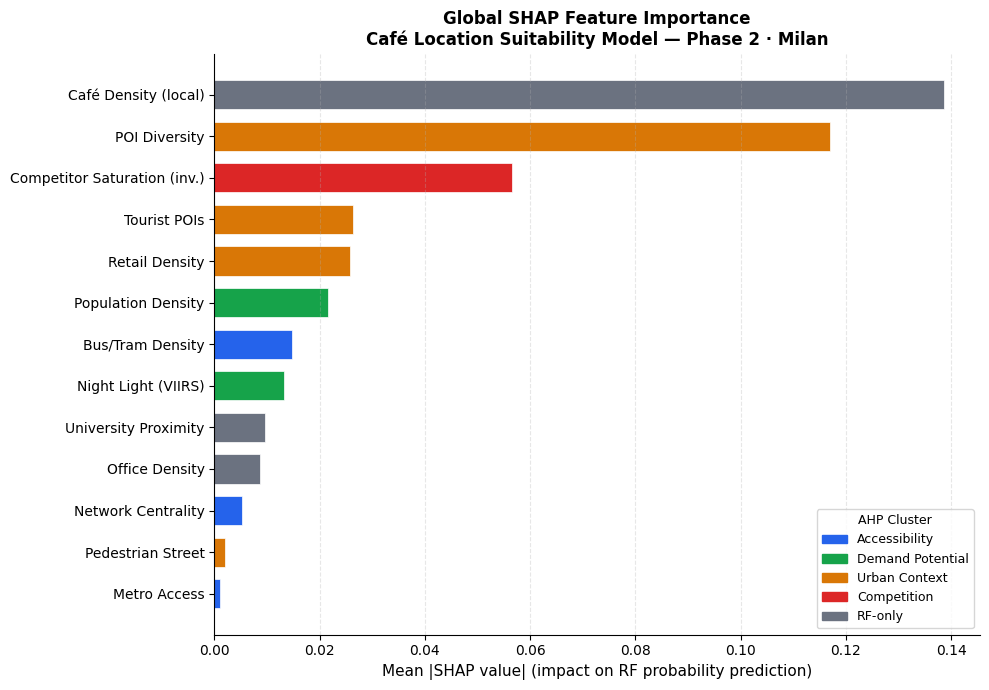

SHAP bar plot saved: gold_shap_bar.png


In [ ]:
# =============================================================================
# VISUALIZATION 1 — SHAP BAR PLOT (Mean Absolute SHAP Importance)
# =============================================================================
#
# This is the publication-quality figure for the thesis.
# Color-coded by AHP cluster to visually connect SHAP findings
# back to the expert framework structure.

print("Generating SHAP bar importance plot...")

CLUSTER_COLORS = {
    'Accessibility':    '#2563EB',   # Blue
    'Demand Potential': '#16A34A',   # Green
    'Urban Context':    '#D97706',   # Amber
    'Competition':      '#DC2626',   # Red
    'RF-only':          '#6B7280',   # Gray — canonical string, covers all 3 RF-only features
}

# Sort by SHAP importance descending for the bar chart
plot_df = comparison_df.sort_values('mean_abs_shap', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

colors = [CLUSTER_COLORS.get(c, '#6B7280') for c in plot_df['ahp_cluster']]
bars   = ax.barh(
    plot_df['feature_name'],
    plot_df['mean_abs_shap'],
    color=colors,
    edgecolor='white',
    linewidth=0.5,
    height=0.7
)

ax.set_xlabel('Mean |SHAP value| (impact on RF probability prediction)',
              fontsize=11)
ax.set_title('Global SHAP Feature Importance\n'
             'Café Location Suitability Model — Phase 2 · Milan',
             fontsize=12, fontweight='bold')
ax.set_xlim(left=0)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

# Legend for AHP clusters
legend_patches = [
    mpatches.Patch(color=CLUSTER_COLORS[c], label=c)
    for c in ['Accessibility', 'Demand Potential',
              'Urban Context', 'Competition', 'RF-only']
]
ax.legend(handles=legend_patches, title='AHP Cluster',
          loc='lower right', fontsize=9, title_fontsize=9)

plt.tight_layout()
bar_path = os.path.join(GOLD_PATH, 'gold_shap_bar.png')
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"SHAP bar plot saved: gold_shap_bar.png")

# Cell 10

Generating SHAP beeswarm plot...


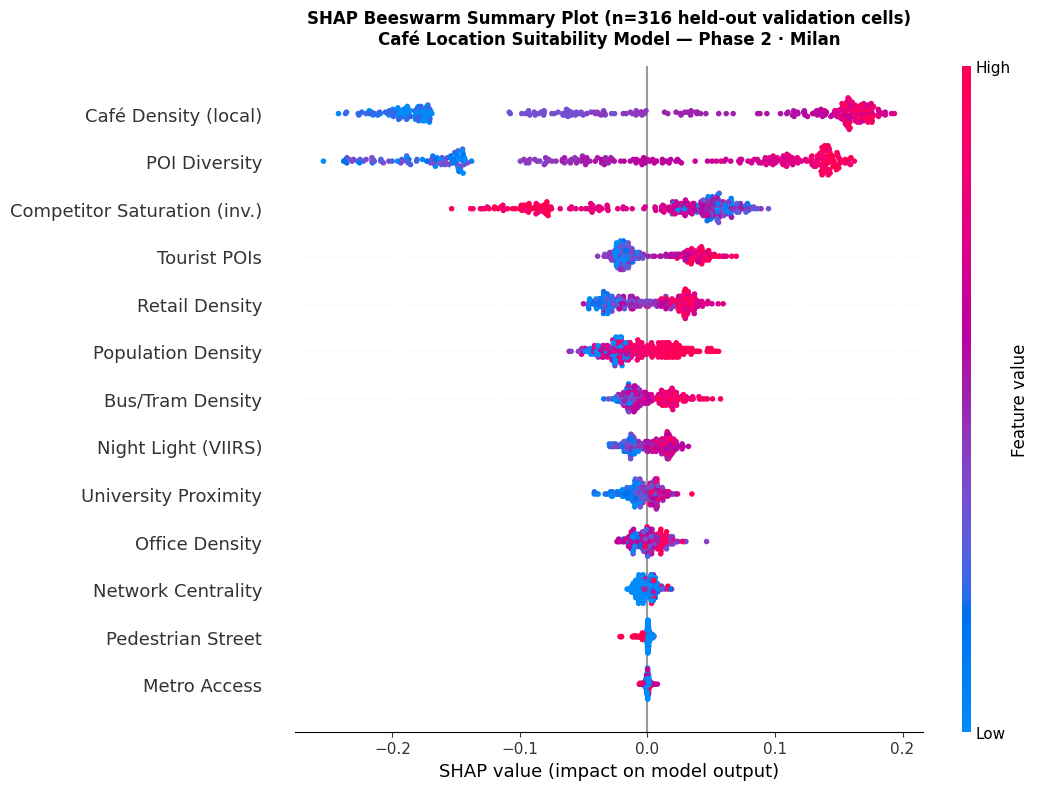

SHAP beeswarm plot saved: gold_shap_beeswarm.png


In [ ]:
# =============================================================================
# VISUALIZATION 2 — SHAP BEESWARM SUMMARY PLOT
# =============================================================================
#
# The beeswarm plot shows both the magnitude (x-axis) AND direction
# (positive vs negative SHAP) AND the feature value (color)
# for every single cell in the dataset.
#
# Beeswarm now uses validation-set cells only
# (val_idx), consistent with the bar plot in Cell 9. Both primary SHAP
# publication figures now reflect the same held-out population.

print("Generating SHAP beeswarm plot...")

# Build a shap.Explanation object using validation-set cells only
shap_explanation = shap.Explanation(
    values=shap_values[val_idx, :],
    base_values=np.full(len(val_idx), base_value),
    data=X_all[val_idx],
    feature_names=display_names
)

fig, ax = plt.subplots(figsize=(11, 8))
shap.plots.beeswarm(
    shap_explanation,
    max_display=13,
    show=False,
    plot_size=None
)
plt.title(f'SHAP Beeswarm Summary Plot (n={len(val_idx)} held-out validation cells)\n'
          'Café Location Suitability Model — Phase 2 · Milan',
          fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
beeswarm_path = os.path.join(GOLD_PATH, 'gold_shap_beeswarm.png')
plt.savefig(beeswarm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"SHAP beeswarm plot saved: gold_shap_beeswarm.png")

# Cell 11

Generating waterfall plots for case study cells...

  Validation cells available for case studies: 316

Case A — Top AHP cell (validation set):
  h3_id:       891f99cdd47ffff
  AHP score:   0.7909  (global rank 2)
  RF prob:     0.9828  (global rank 71)
  label:       1
  [Validation set cell — SHAP reflects generalizable model logic]



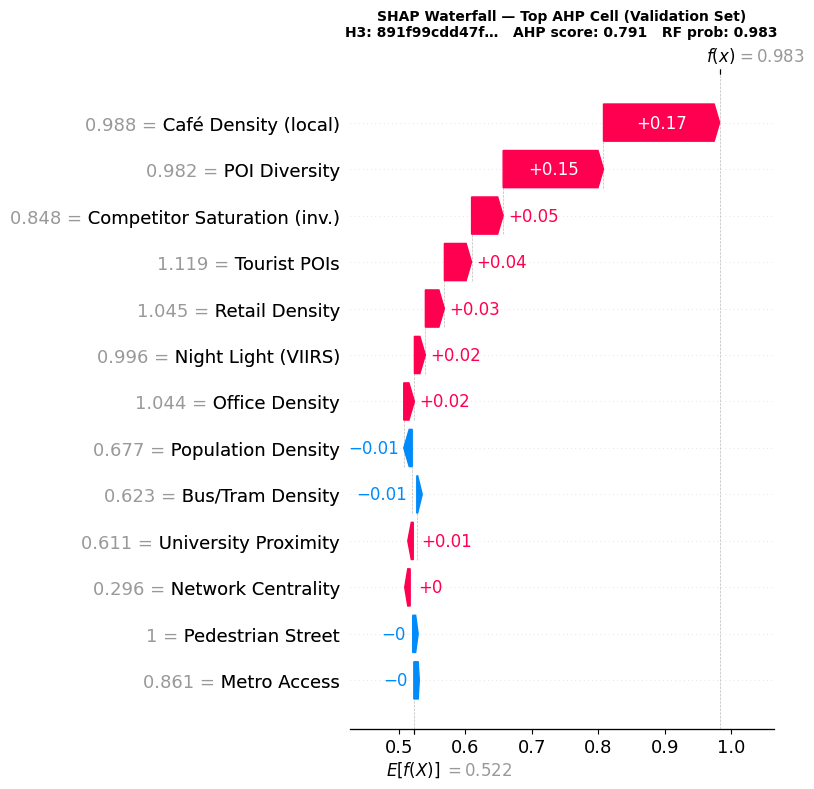

Waterfall (top AHP, val set) saved: gold_shap_waterfall_top1.png

Case B — Maximum AHP vs RF divergence cell (validation set):
  h3_id:       891f99566c3ffff
  AHP score:   0.3729  (rank 828)
  RF prob:     0.8492  (rank 281)
  |Δ rank|:    547
  label:       0
  [Validation set cell — divergence reflects genuine model disagreement]



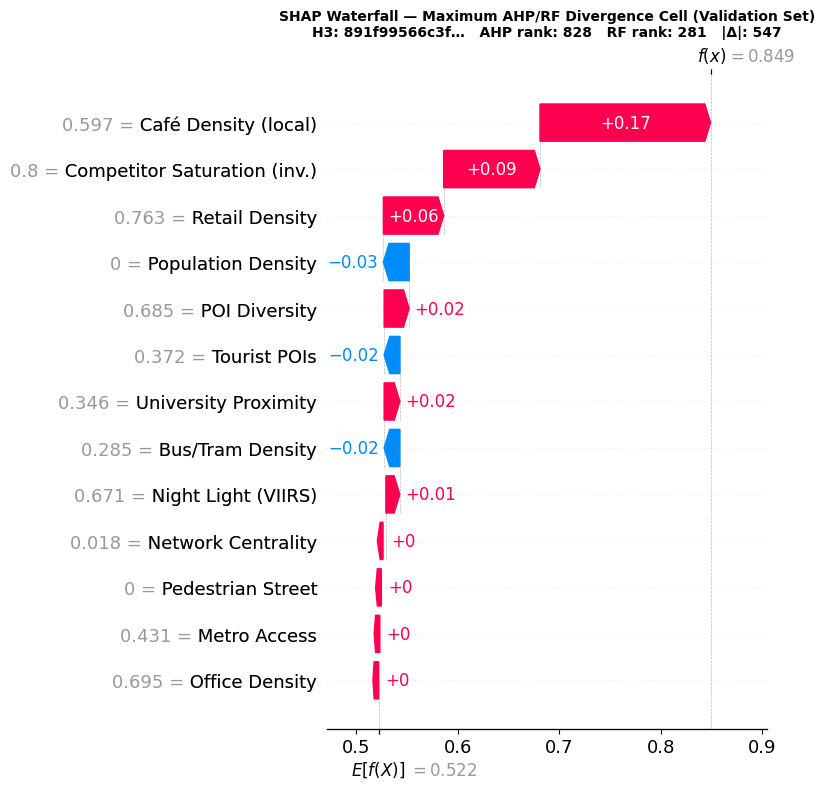

Waterfall (divergent, val set) saved: gold_shap_waterfall_divergent.png


In [ ]:
# =============================================================================
# VISUALIZATION 3 — WATERFALL PLOTS FOR INDIVIDUAL CELLS
# =============================================================================
#
# Waterfall plots decompose a single cell's prediction into its
# SHAP contributions. They show:
#   - The base value (mean prediction)
#   - Each feature's additive contribution (positive = pushes toward suitable)
#   - The final RF probability for that cell
#
# Two cells are selected:
#   (a) The cell ranked #1 by AHP score within the validation set
#   (b) The cell with the largest AHP vs RF rank disagreement within
#       the validation set
#
# IMPORTANT: Both cells are restricted to the held-out validation set
# (val_idx loaded canonically in Cell 5). This ensures the waterfall
# plots reflect the model's generalizable logic, not patterns memorised
# during training.
#
# val_idx loading block is absent here by design.
# val_idx is already bound from Cell 5 (canonical gold_train_val_idx.pkl).
# Re-deriving it here via a separate code path risks silent overwrites.

print("Generating waterfall plots for case study cells...")
print()

assert len(val_idx) > 0, "val_idx not in scope — run Cells 5 and 6 first"

# shap_explanation was built on val_idx rows in Cell 10.
# All indexing here must use positions LOCAL to val_idx (0..n_val-1),
# not positions in the full X_all array.

# Subset the features GeoDataFrame to validation cells only
features_val = features.iloc[val_idx].reset_index(drop=False)
# 'index' column now holds the original position in features / X_all
print(f"  Validation cells available for case studies: {len(features_val)}")
print()

# ── (a) Top AHP cell — highest AHP score within validation set ────────────────
top_ahp_local_pos = features_val['ahp_rank'].idxmin()   # local position in features_val
top_ahp_val_idx_label = features_val.loc[top_ahp_local_pos, 'index']   # original label

top_ahp_cell  = features_val.loc[top_ahp_local_pos, 'h3_id']
top_ahp_prob  = features_val.loc[top_ahp_local_pos, 'rf_probability']
top_ahp_score = features_val.loc[top_ahp_local_pos, 'ahp_score']

print(f"Case A — Top AHP cell (validation set):")
print(f"  h3_id:       {top_ahp_cell}")
print(f"  AHP score:   {top_ahp_score:.4f}  "
      f"(global rank {int(features_val.loc[top_ahp_local_pos, 'ahp_rank'])})")
print(f"  RF prob:     {top_ahp_prob:.4f}  "
      f"(global rank {int(features_val.loc[top_ahp_local_pos, 'rf_rank'])})")
print(f"  label:       {int(features_val.loc[top_ahp_local_pos, 'label'])}")
print(f"  [Validation set cell — SHAP reflects generalizable model logic]")
print()

fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.waterfall(
    shap_explanation[top_ahp_local_pos],   # local index into val-only Explanation
    max_display=13,
    show=False
)
plt.title(f'SHAP Waterfall — Top AHP Cell (Validation Set)\n'
          f'H3: {top_ahp_cell[:12]}…   '
          f'AHP score: {top_ahp_score:.3f}   '
          f'RF prob: {top_ahp_prob:.3f}',
          fontsize=10, fontweight='bold')
plt.tight_layout()
wf_ahp_path = os.path.join(GOLD_PATH, 'gold_shap_waterfall_top1.png')
plt.savefig(wf_ahp_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Waterfall (top AHP, val set) saved: gold_shap_waterfall_top1.png")
print()

# ── (b) Maximum AHP vs RF rank divergence cell — validation set only ──────────
max_div_local_pos = features_val['rank_diff'].idxmax()   # local position in features_val

max_divergent_cell = features_val.loc[max_div_local_pos, 'h3_id']
div_ahp_rank       = int(features_val.loc[max_div_local_pos, 'ahp_rank'])
div_rf_rank        = int(features_val.loc[max_div_local_pos, 'rf_rank'])
div_rank_diff      = int(features_val.loc[max_div_local_pos, 'rank_diff'])
div_ahp_score      = features_val.loc[max_div_local_pos, 'ahp_score']
div_rf_prob        = features_val.loc[max_div_local_pos, 'rf_probability']

print(f"Case B — Maximum AHP vs RF divergence cell (validation set):")
print(f"  h3_id:       {max_divergent_cell}")
print(f"  AHP score:   {div_ahp_score:.4f}  (rank {div_ahp_rank})")
print(f"  RF prob:     {div_rf_prob:.4f}  (rank {div_rf_rank})")
print(f"  |Δ rank|:    {div_rank_diff}")
print(f"  label:       {int(features_val.loc[max_div_local_pos, 'label'])}")
print(f"  [Validation set cell — divergence reflects genuine model disagreement]")
print()

fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.waterfall(
    shap_explanation[max_div_local_pos],   # local index into val-only Explanation
    max_display=13,
    show=False
)
plt.title(f'SHAP Waterfall — Maximum AHP/RF Divergence Cell (Validation Set)\n'
          f'H3: {max_divergent_cell[:12]}…   '
          f'AHP rank: {div_ahp_rank}   '
          f'RF rank: {div_rf_rank}   '
          f'|Δ|: {div_rank_diff}',
          fontsize=10, fontweight='bold')
plt.tight_layout()
wf_div_path = os.path.join(GOLD_PATH, 'gold_shap_waterfall_divergent.png')
plt.savefig(wf_div_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Waterfall (divergent, val set) saved: gold_shap_waterfall_divergent.png")

# Cell 12

In [ ]:
# =============================================================================
# CELL 12 — Export per-cell SHAP vectors to GeoJSON (for WebGIS)
# =============================================================================

print("Exporting per-cell SHAP vectors to GeoJSON...")
print()

# Build SHAP columns
shap_df = pd.DataFrame(
    shap_values,
    columns=[f'shap_{col}' for col in FEATURE_COLS],
    index=features.index
)

# Add the base value as a column for WebGIS use
shap_df['shap_base_value'] = base_value

# Add is_validation_cell boolean flag
# True for cells in the held-out validation set; False for training cells.
# All SHAP importance rankings and AHP vs SHAP comparisons in the thesis
# are computed from validation-set cells only (is_validation_cell == True).
is_val = np.zeros(len(features), dtype=bool)
is_val[val_idx] = True
shap_df['is_validation_cell'] = is_val

# Merge onto feature GeoDataFrame
output_gdf = features[[
    'h3_id', 'label', 'cafe_count',
    'ahp_score', 'ahp_rank',
    'rf_probability', 'rf_rank',
    'rank_diff',
    'geometry'
]].copy()

for col in shap_df.columns:
    output_gdf[col] = shap_df[col].values

print(f"Output GeoDataFrame: {output_gdf.shape}")
print(f"  is_validation_cell: {is_val.sum()} validation cells flagged "
      f"({(~is_val).sum()} training cells)")
print(f"  Columns: {list(output_gdf.columns)}")
print()

if output_gdf.crs and output_gdf.crs.to_epsg() != 4326:
    output_gdf = output_gdf.to_crs('EPSG:4326')

shap_geojson_path = os.path.join(GOLD_PATH, 'gold_shap_scores.geojson')
output_gdf.to_file(shap_geojson_path, driver='GeoJSON')
print(f"SHAP scores GeoJSON saved: gold_shap_scores.geojson")
print(f"  {len(output_gdf)} cells × {len(output_gdf.columns)} columns")
print(f"  (Includes {len(FEATURE_COLS)} SHAP feature columns + base_value + is_validation_cell)")

Exporting per-cell SHAP vectors to GeoJSON...

Output GeoDataFrame: (971, 24)
  is_validation_cell: 316 validation cells flagged (655 training cells)
  Columns: ['h3_id', 'label', 'cafe_count', 'ahp_score', 'ahp_rank', 'rf_probability', 'rf_rank', 'rank_diff', 'geometry', 'shap_metro_count_norm', 'shap_transit_density_norm', 'shap_network_centrality_norm', 'shap_pop_density_norm', 'shap_night_light_norm', 'shap_retail_density_norm', 'shap_tourist_poi_count_norm', 'shap_poi_diversity_norm', 'shap_pedestrian_street', 'shap_competitor_saturation_inv_norm', 'shap_local_cafe_density_norm', 'shap_office_density_norm', 'shap_university_proximity_norm', 'shap_base_value', 'is_validation_cell']

SHAP scores GeoJSON saved: gold_shap_scores.geojson
  971 cells × 24 columns
  (Includes 13 SHAP feature columns + base_value + is_validation_cell)


# Cell 13

In [ ]:
# =============================================================================
# CELL 13 — Thesis Summary Statistics
# =============================================================================

import json as _json

print("=" * 65)
print("NOTEBOOK 7 — THESIS SUMMARY STATISTICS")
print("=" * 65)
print()

# --- Load NB6 cell-level Spearman rho dynamically ----------------------------
_perf_path = os.path.join(GOLD_PATH, 'gold_performance.json')
if os.path.exists(_perf_path):
    with open(_perf_path, 'r') as _f:
        perf_nb6 = _json.load(_f)
    _cell_rho   = perf_nb6.get('spearman_ahp_rf_cell_level', 'n/a')
    _cell_pval  = perf_nb6.get('spearman_ahp_rf_pvalue',     'n/a')
    _val_auc    = perf_nb6.get('rf_auc_validation',          'n/a')
    _cv_auc     = perf_nb6.get('rf_cv_auc_mean',             'n/a')
    _cv_auc_std = perf_nb6.get('rf_cv_auc_std',              'n/a')
else:
    perf_nb6    = {}
    _cell_rho   = 'MISSING — run NB6 first'
    _cell_pval  = 'n/a'
    _val_auc    = 'n/a'
    _cv_auc     = 'n/a'
    _cv_auc_std = 'n/a'
    print("  WARNING: gold_performance.json not found.")
    print("  Run Notebook 6 before Notebook 7 to populate this file.")
    print()

print("─── Model Performance (from gold_performance.json — NB6) ───")
print(f"  AUC (validation set, natural distribution): {_val_auc}")
print(f"  Cross-validation AUC (balanced):            {_cv_auc} ± {_cv_auc_std}")
print(f"  [Balanced CV and natural-distribution holdout are DISTINCT metrics]")
print()

print("─── AHP–RF Cell-Level Agreement (from gold_performance.json — NB6) ───")
print(f"  Spearman ρ (AHP score vs RF probability, val set):  {_cell_rho}")
print(f"  p-value:                                            {_cell_pval}")
print()

print("─── AHP–SHAP Feature-Level Agreement (this notebook — val set) ───")
print(f"  Spearman ρ (AHP eff. weights vs SHAP importance):   "
      f"{rho_ahp_shap:.4f}")
print(f"  Kendall  τ (AHP eff. weights vs SHAP importance):   "
      f"{tau_ahp_shap:.4f}")
print(f"  p-value (Spearman): {pval_ahp_shap:.4f}")
print(f"  [SHAP importance computed on {len(val_idx)}-cell held-out validation set]")
print()

print("─── Top 3 Features by SHAP Importance (validation set) ───")
top3 = comparison_df.nsmallest(3, 'shap_rank')
for _, row in top3.iterrows():
    ahp_rank_str = str(int(row['ahp_rank'])) if pd.notna(row['ahp_rank']) else 'N/A (RF-only)'
    print(f"  #{int(row['shap_rank'])}: {row['feature_name']:<34} "
          f"mean|SHAP|={row['mean_abs_shap']:.6f}  "
          f"AHP rank: {ahp_rank_str}")
print()

print("─── Top 3 Features by AHP Effective Weight ───")
top3_ahp = comparison_df[comparison_df['ahp_cluster'] != 'RF-only'].nsmallest(3, 'ahp_rank')
for _, row in top3_ahp.iterrows():
    print(f"  #{int(row['ahp_rank'])}: {row['feature_name']:<34} "
          f"AHP_eff_w={row['ahp_effective_w']:.4f}  "
          f"SHAP rank: {int(row['shap_rank'])}")
print()

print("─── Largest Rank Divergences (AHP features only) ───")
# Filter to AHP features before nlargest — RF-only rank_diff is NaN and must not
# appear here, as their ahp_rank is undefined and any divergence is meaningless.
top3_div = (
    comparison_df[comparison_df['ahp_cluster'] != 'RF-only']
    .nlargest(3, 'rank_diff')
)
for _, row in top3_div.iterrows():
    print(f"  {row['feature_name']:<34} "
          f"AHP rank: {int(row['ahp_rank']):<4} "
          f"SHAP rank: {int(row['shap_rank']):<4} "
          f"|Δ|={int(row['rank_diff'])}  "
          f"{row['direction']}")
print()

print("─── RF-only Features (excluded from AHP) ───")
rf_only_rows_13 = comparison_df[comparison_df['ahp_cluster'] == 'RF-only']
for _, row in rf_only_rows_13.sort_values('shap_rank').iterrows():
    print(f"  {row['feature_name']:<34} "
          f"SHAP rank: {int(row['shap_rank'])}  "
          f"mean|SHAP|={row['mean_abs_shap']:.6f}")
print()

print("─── Maximum AHP vs RF Cell Divergence (validation set) ───")
print(f"  Cell h3_id: {max_divergent_cell}")
print(f"  AHP rank:   {div_ahp_rank}  (score: {div_ahp_score:.4f})")
print(f"  RF rank:    {div_rf_rank}   (prob:  {div_rf_prob:.4f})")
print(f"  |Δ rank|:   {div_rank_diff}")
print(f"  [Restricted to validation set for academic integrity]")
print()

print("─── SHAP Base Value ───")
print(f"  Mean RF prediction (base value): {base_value:.4f}")
print(f"  Natural positive class rate:     see NB6 log")
print(f"  NOTE: Base value > natural class rate is EXPECTED — RF was trained")
print(f"  on a balanced 50/50 set, so base value reflects training distribution.")
print()

print("=" * 65)

NOTEBOOK 7 — THESIS SUMMARY STATISTICS

─── Model Performance (from gold_performance.json — NB6) ───
  AUC (validation set, natural distribution): 0.951
  Cross-validation AUC (balanced):            0.9462 ± 0.0211
  [Balanced CV and natural-distribution holdout are DISTINCT metrics]

─── AHP–RF Cell-Level Agreement (from gold_performance.json — NB6) ───
  Spearman ρ (AHP score vs RF probability, val set):  0.7937
  p-value:                                            0.0

─── AHP–SHAP Feature-Level Agreement (this notebook — val set) ───
  Spearman ρ (AHP eff. weights vs SHAP importance):   -0.4073
  Kendall  τ (AHP eff. weights vs SHAP importance):   -0.3146
  p-value (Spearman): 0.2427
  [SHAP importance computed on 316-cell held-out validation set]

─── Top 3 Features by SHAP Importance (validation set) ───
  #1: Café Density (local)               mean|SHAP|=0.138575  AHP rank: N/A (RF-only)
  #2: POI Diversity                      mean|SHAP|=0.116915  AHP rank: 8
  #3: Competitor S

# Cell 14

In [ ]:
# =============================================================================
# CELL 14 — LOG FILE
# Ensure all referenced variables are defined before building log_lines.
# rf_only_variance_fraction and ahp_total_shap_share are recomputed here
# defensively in case Cell 8 ran an older version without the fix.
# =============================================================================

import json as _json

# ── Defensive recomputation of variance fractions ─────────────────────────────
# 'RF-only' is the canonical string for all three Phase 2 RF-only features.
total_shap_all_features_log = comparison_df['mean_abs_shap'].sum()

_rf_only_rows = comparison_df[comparison_df['ahp_cluster'] == 'RF-only']
if len(_rf_only_rows) > 0:
    _rf_only_shap_log         = _rf_only_rows['mean_abs_shap'].sum()   # sum all RF-only
    rf_only_variance_fraction = _rf_only_shap_log / total_shap_all_features_log
else:
    _rf_only_shap_log         = 0.0
    rf_only_variance_fraction = 0.0

_ahp_rows = comparison_df[comparison_df['ahp_cluster'] != 'RF-only']
ahp_total_shap_share = (
    _ahp_rows['mean_abs_shap'].sum() / total_shap_all_features_log
)

# ── Load NB6 performance metrics dynamically ──────────────────────────────────
_perf_path = os.path.join(GOLD_PATH, 'gold_performance.json')
if os.path.exists(_perf_path):
    with open(_perf_path, 'r') as _f:
        perf_nb6 = _json.load(_f)
else:
    perf_nb6 = {}
    print("  WARNING: gold_performance.json not found — NB6 metrics will "
          "show as placeholders in log")

# ── Build log ─────────────────────────────────────────────────────────────────
log_lines = [
    f"Thesis — Phase 2 · SHAP Computation and AHP vs SHAP Comparison Log",
    f"====================================================================",
    f"Run date:              {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}",
    f"",
    f"SHAP configuration:",
    f"  Explainer:           TreeExplainer (exact, no sampling)",
    f"  Background:          X_train (balanced training set, n={X_train_nb7.shape[0]})",
    f"                       (grounds base_value in training distribution — Action Item 9)",
    f"  Base value:          {base_value:.4f}",
    f"  Model output:        probability (positive class)",
    f"  SHAP additivity max error: {max_error:.6f} [{'PASS' if max_error < 0.01 else 'WARN'} < 0.01]",
    f"",
    f"Global SHAP importance: computed on held-out validation set only",
    f"  Validation cells: {len(val_idx)}",
    f"  Training memorization excluded from importance ranking",
    f"",
    f"RF-only feature variance disclosure (Phase 2 — 3 features):",
    f"  Combined RF-only SHAP share:   {rf_only_variance_fraction*100:.1f}% of total model variance",
    f"  AHP clusters SHAP share:       {ahp_total_shap_share*100:.1f}% of total model variance",
    f"",
    f"is_validation_cell flag added to gold_shap_scores.geojson",
    f"  True for {is_val.sum()} validation cells, "
    f"False for {(~is_val).sum()} training cells",
    f"",
    f"AHP vs SHAP feature-level agreement (ahp_eff_weights vs shap_mean_abs):",
    f"  Spearman rho:        {rho_ahp_shap:.4f}  (p={pval_ahp_shap:.4f})",
    f"  Kendall tau:         {tau_ahp_shap:.4f}  (p={pval_tau:.4f})",
    f"  Features in AHP (Phase 2): {mask_ahp_features.sum()} "
    f"(excl. RF-only: local_cafe_density, office_density, university_proximity)",
    f"",
    f"Feature-level permutation null distribution (Task 2):",
    f"  N permutations:      10,000",
    f"  Null 95% interval:   [{perm_null_p2_5_feat:.4f}, {perm_null_p97_5_feat:.4f}]",
    f"  Empirical p (2-tail):{perm_pval_feat:.4f}",
    f"  Null result confirmed: {not perm_flag_feat_outside_95}",
    f"",
    f"AHP vs RF cell-level agreement (from NB6):",
    f"  Spearman rho:        "
    f"{perf_nb6.get('spearman_ahp_rf_cell_level', 'see gold_performance.json')}  "
    f"(p={perf_nb6.get('spearman_ahp_rf_pvalue', 'n/a')})  [validation set only]",
    f"",
    f"Top 5 features by SHAP importance (validation set):",
]

for _, row in comparison_df.nsmallest(5, 'shap_rank').iterrows():
    ahp_rank_log = int(row['ahp_rank']) if pd.notna(row['ahp_rank']) else 'N/A'
    rank_diff_log = int(row['rank_diff']) if pd.notna(row['rank_diff']) else 'N/A'
    log_lines.append(
        f"  #{int(row['shap_rank'])}: {row['feature_name']:<34} "
        f"mean|SHAP|={row['mean_abs_shap']:.6f}  "
        f"AHP_rank={ahp_rank_log}  Δ={rank_diff_log}"
    )

log_lines.extend([
    f"",
    f"Largest AHP vs SHAP rank divergences (AHP features only — RF-only excluded):",
])
for _, row in (
    comparison_df[comparison_df['ahp_cluster'] != 'RF-only']
    .nlargest(3, 'rank_diff')
    .iterrows()
):
    log_lines.append(
        f"  {row['feature_name']:<34} "
        f"AHP={int(row['ahp_rank'])} SHAP={int(row['shap_rank'])} "
        f"|Δ|={int(row['rank_diff'])} {row['direction']}"
    )

log_lines.extend([
    f"",
    f"Case study cells (both restricted to validation set):",
    f"  Top AHP cell:        {top_ahp_cell}",
    f"    AHP score: {top_ahp_score:.4f}  RF prob: {top_ahp_prob:.4f}",
    f"  Max divergence cell: {max_divergent_cell}",
    f"    AHP rank: {div_ahp_rank}  RF rank: {div_rf_rank}  |Δ|: {div_rank_diff}",
    f"",
    f"Outputs:",
    f"  gold_shap_scores.geojson         (includes is_validation_cell flag)",
    f"  gold_shap_importance.csv",
    f"  gold_ahp_vs_shap_comparison.csv",
    f"  gold_shap_bar.png",
    f"  gold_shap_beeswarm.png",
    f"  gold_shap_waterfall_top1.png",
    f"  gold_shap_waterfall_divergent.png",
    f"  gold_nb7_log.txt",
])

log_path = os.path.join(GOLD_PATH, 'gold_nb7_log.txt')
with open(log_path, 'w') as f:
    f.write('\n'.join(log_lines))

print('\n'.join(log_lines))
print(f"\nLog saved to: {log_path}")

Thesis — Phase 2 · SHAP Computation and AHP vs SHAP Comparison Log
Run date:              2026-04-26 13:01

SHAP configuration:
  Explainer:           TreeExplainer (exact, no sampling)
  Background:          X_train (balanced training set, n=416)
                       (grounds base_value in training distribution — Action Item 9)
  Base value:          0.5222
  Model output:        probability (positive class)
  SHAP additivity max error: 0.004992 [PASS < 0.01]

Global SHAP importance: computed on held-out validation set only
  Validation cells: 316
  Training memorization excluded from importance ranking

RF-only feature variance disclosure (Phase 2 — 3 features):
  Combined RF-only SHAP share:   35.6% of total model variance
  AHP clusters SHAP share:       64.4% of total model variance

is_validation_cell flag added to gold_shap_scores.geojson
  True for 316 validation cells, False for 655 training cells

AHP vs SHAP feature-level agreement (ahp_eff_weights vs shap_mean_abs):
  Spe

# Cell 15

In [ ]:
print("=" * 60)
print("NOTEBOOK 7 COMPLETE")
print("=" * 60)

expected_files = [
    'gold_shap_scores.geojson',
    'gold_shap_importance.csv',
    'gold_ahp_vs_shap_comparison.csv',
    'gold_shap_bar.png',
    'gold_shap_beeswarm.png',
    'gold_shap_waterfall_top1.png',
    'gold_shap_waterfall_divergent.png',
    'gold_nb7_log.txt',
]

all_present = True
for filename in expected_files:
    filepath = os.path.join(GOLD_PATH, filename)
    status   = "OK" if os.path.exists(filepath) else "MISSING"
    if status == "MISSING":
        all_present = False
    print(f"  [{status}] {filename}")

print()
print(f"  SHAP base value:            {base_value:.4f}")
print(f"  SHAP additivity max error:  {max_error:.6f}")
print(f"  ρ_AHP_SHAP (feature-level): {rho_ahp_shap:.4f}")
print(f"  ρ_AHP_RF   (cell-level):    "
      f"{perf_nb6.get('spearman_ahp_rf_cell_level', 'see gold_performance.json')}"
      f"  [from NB6 gold_performance.json]")
print()

if all_present:
    print("All outputs present.")
    print()
    print("Phase 2 pipeline complete:")
    print("  NB1 → NB2 → NB3 → NB4 → NB5 → NB6 → NB7 ✓")
    print()
    print("Ready to proceed to Notebook 8 — GeoJSON export for WebGIS.")
    print("  NB8 will produce the final flat GeoJSON for the Phase 3")
    print("  frontend with all scores, SHAP values, and display attributes.")
else:
    print("Some files missing. Review cells above before proceeding.")

NOTEBOOK 7 COMPLETE
  [OK] gold_shap_scores.geojson
  [OK] gold_shap_importance.csv
  [OK] gold_ahp_vs_shap_comparison.csv
  [OK] gold_shap_bar.png
  [OK] gold_shap_beeswarm.png
  [OK] gold_shap_waterfall_top1.png
  [OK] gold_shap_waterfall_divergent.png
  [OK] gold_nb7_log.txt

  SHAP base value:            0.5222
  SHAP additivity max error:  0.004992
  ρ_AHP_SHAP (feature-level): -0.4073
  ρ_AHP_RF   (cell-level):    0.7937  [from NB6 gold_performance.json]

All outputs present.

Phase 2 pipeline complete:
  NB1 → NB2 → NB3 → NB4 → NB5 → NB6 → NB7 ✓

Ready to proceed to Notebook 8 — GeoJSON export for WebGIS.
  NB8 will produce the final flat GeoJSON for the Phase 3
  frontend with all scores, SHAP values, and display attributes.
